In [33]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DZ = 0.05                                    # sample spacing (m)
FILES = {'ALHIC2201': '~/Downloads/ALHIC2201_CFA_(water-isotopes-CH4-dust).csv',
         'ALHIC2302': '~/Downloads/ALHIC2302_CFA_(water-isotopes-CH4-dust).csv'}
PROXIES = ['d18O', 'dD', 'CH4']
TIERNEY = {'d18O': 30, 'dD': 30, 'CH4': 75}  # Tierney & Ibarra mixing lengths (cm)
SIGMA_TEST = 5                               # small sigma to compare against


In [34]:
def longest_stretch(core, proxy):
    # longest gap-free run of this proxy, on an exact 5 cm grid
    df = pd.read_csv(FILES[core])
    names = {c: p for c in df.columns for p in ['depth'] + PROXIES if c.lower().startswith(p.lower())}
    df = df.rename(columns=names).groupby('depth', as_index=False).mean(numeric_only=True)
    s = df[['depth', proxy]].dropna()
    breaks = np.where(np.diff(s.depth.values) > 0.15)[0] + 1
    idx = max(np.split(np.arange(len(s)), breaks), key=len)
    z_raw, y_raw = s.depth.values[idx], s[proxy].values[idx]
    z = np.round(np.arange(z_raw[0], z_raw[-1] + DZ/2, DZ), 2)
    return z, np.interp(z, z_raw, y_raw)

def setup(core, proxy):
    # Fourier transform of the record, plus the noise level and K read off the spectrum
    z, y = longest_stretch(core, proxy)
    n = len(y); mean = y.mean()
    ext = np.concatenate([(y - mean)[::-1], y - mean, (y - mean)[::-1]])   # mirror the ends
    Y = np.fft.rfft(ext)
    f = np.fft.rfftfreq(len(ext), DZ)              # cycles/m, up to Nyquist = 10
    P = np.abs(Y)**2 / len(ext)                    # power at each frequency

    noise = np.sqrt(np.median(P[f > 8]))           # flat high-frequency floor
    K = np.median(P[f > 8]) / np.mean(P[(f > 0) & (f < 1)])   # noise-to-signal ratio

    def deconvolve(sigma_cm):
        G = np.exp(-2 * np.pi**2 * (sigma_cm/100)**2 * f**2)   # blur transfer function
        W = G / (G**2 + K)                                     # Wiener filter
        back = lambda S: np.fft.irfft(S, n=len(ext))[n:2*n] + mean
        deconvolved, reblurred = back(W * Y), back(G * W * Y)
        residual_ratio = np.sqrt(np.mean((reblurred - y)**2)) / noise
        return deconvolved, reblurred, residual_ratio

    return z, y, noise, K, deconvolve


In [35]:
def pipeline(core, proxy):
    z, y, noise, K, deconvolve = setup(core, proxy)
    sigma_T = TIERNEY[proxy]
    small, tierney = deconvolve(SIGMA_TEST), deconvolve(sigma_T)

    print(f'=== {core}  {proxy}   {z[0]}-{z[-1]} m, {len(y)} samples ===')
    print(f'noise = {noise:.3g}   K = {K:.3g}   measured range = {np.ptp(y):.2f}')

    fig, ax = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    ax[0].plot(z, y, 'k'); ax[0].set_title(f'{core}  {proxy}: measured')
    for a in ax[1:]:
        a.plot(z, y, color='0.75', lw=3, label='measured')     # thick pale line underneath
    for (deconvolved, reblurred, ratio), sigma_cm, color in [(small, SIGMA_TEST, 'C2'),
                                                             (tierney, sigma_T, 'C3')]:
        ax[1].plot(z, deconvolved, color, lw=1, label=f'σ = {sigma_cm} cm')
        ax[2].plot(z, reblurred, color, lw=1, label=f'σ = {sigma_cm} cm ({ratio:.1f}× noise)')
    ax[1].set_title('deconvolved'); ax[2].set_title('deconvolved, then blurred again')
    ax[2].set_xlabel('depth (m)')
    for a in ax[1:]: a.legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()

    return {'core': core, 'proxy': proxy, 'measured range': np.ptp(y), 'noise': noise,
            f'σ={SIGMA_TEST}: range': np.ptp(small[0]),
            f'σ={SIGMA_TEST}: residual/noise': small[2],
            'Tierney σ (cm)': sigma_T,
            'Tierney: range': np.ptp(tierney[0]),
            'Tierney: residual/noise': tierney[2]}


=== ALHIC2201  d18O   56.3-66.1 m, 197 samples ===
noise = 0.122   K = 0.000935   measured range = 5.33


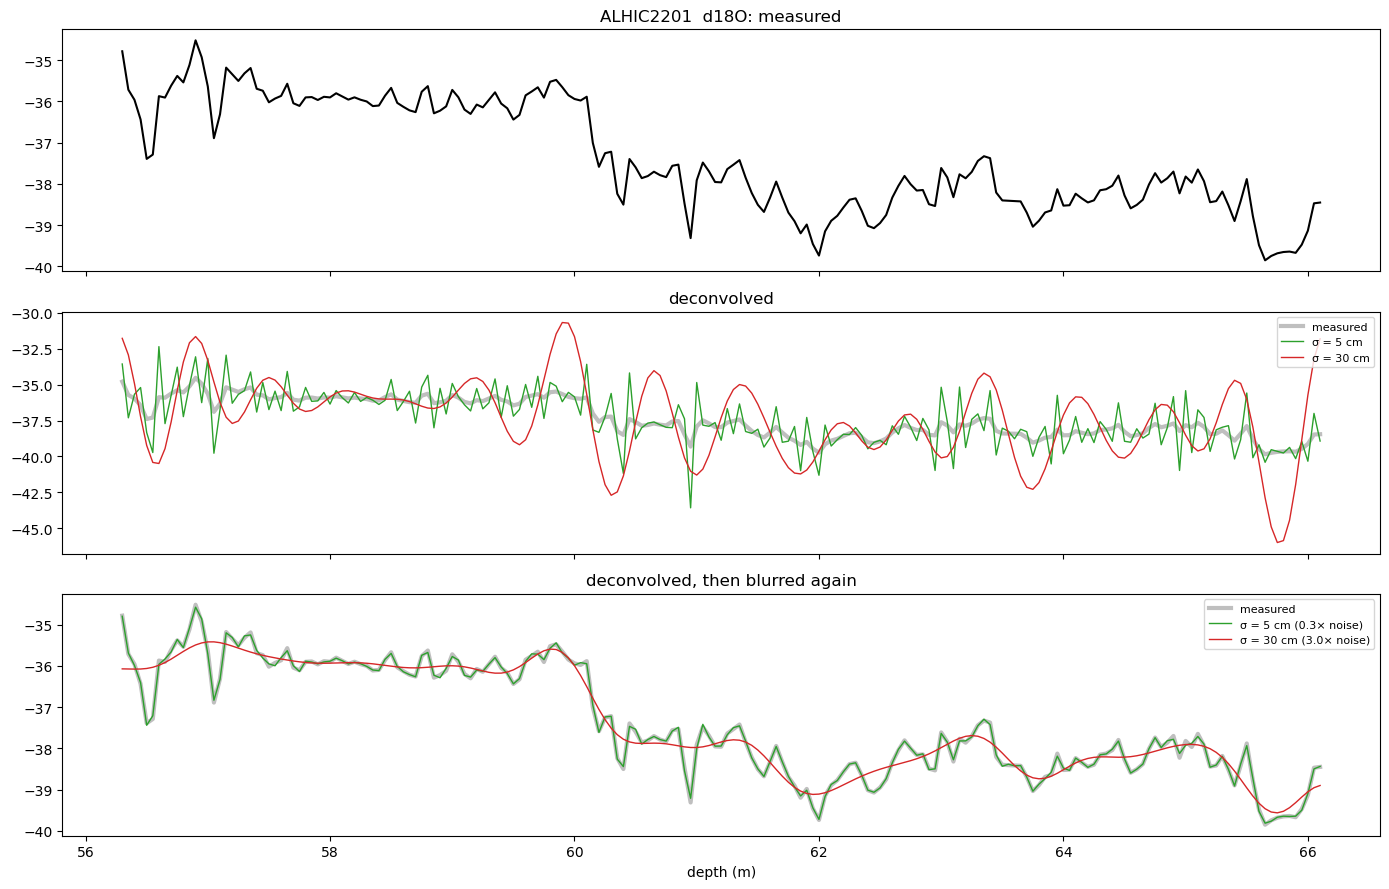

=== ALHIC2201  dD   56.3-66.1 m, 197 samples ===
noise = 0.895   K = 0.000811   measured range = 44.64


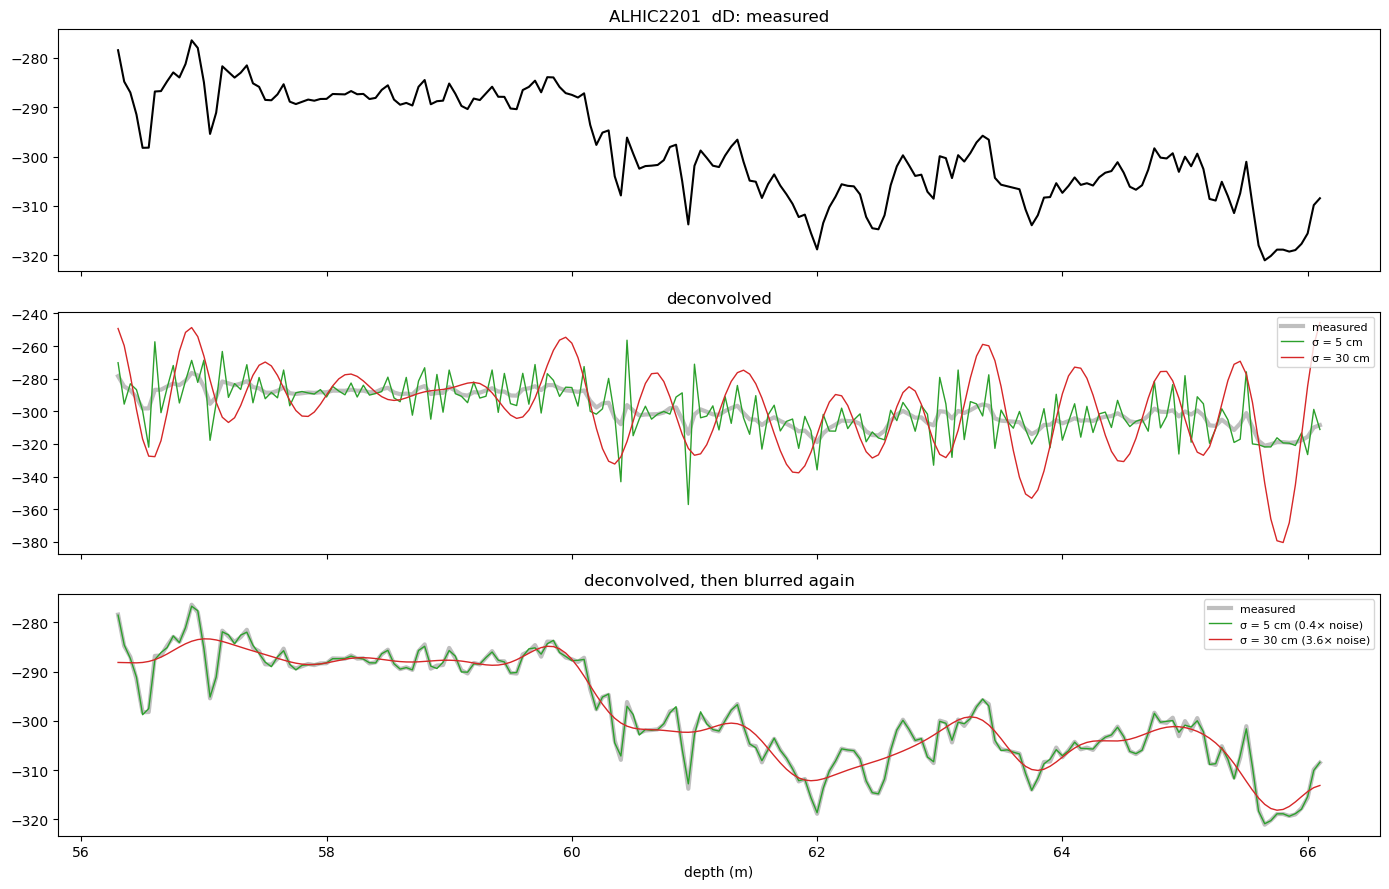

=== ALHIC2201  CH4   56.3-66.1 m, 197 samples ===
noise = 7.3   K = 0.000691   measured range = 323.81


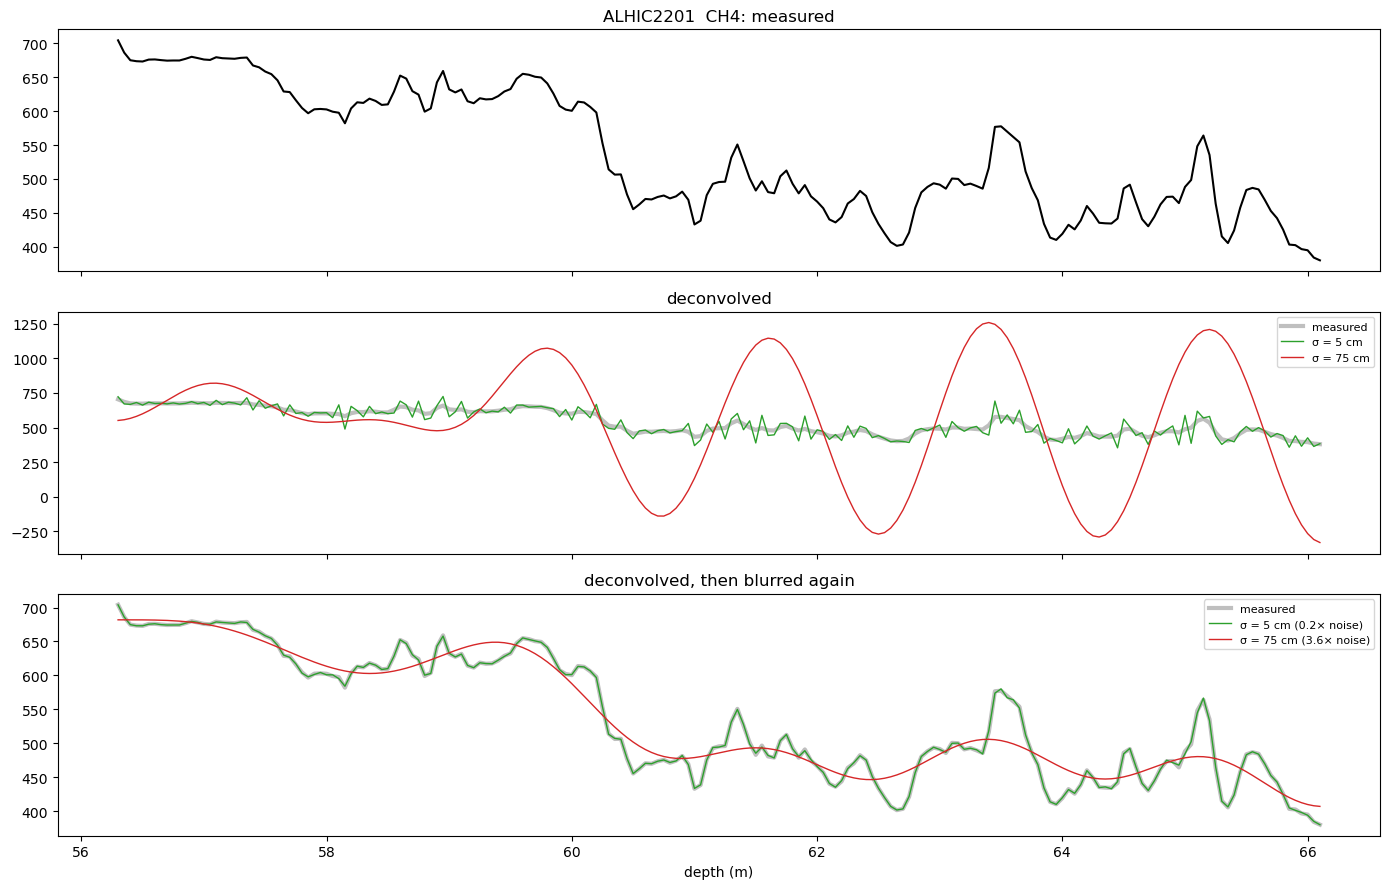

=== ALHIC2302  d18O   28.05-37.05 m, 181 samples ===
noise = 0.046   K = 0.00224   measured range = 2.18


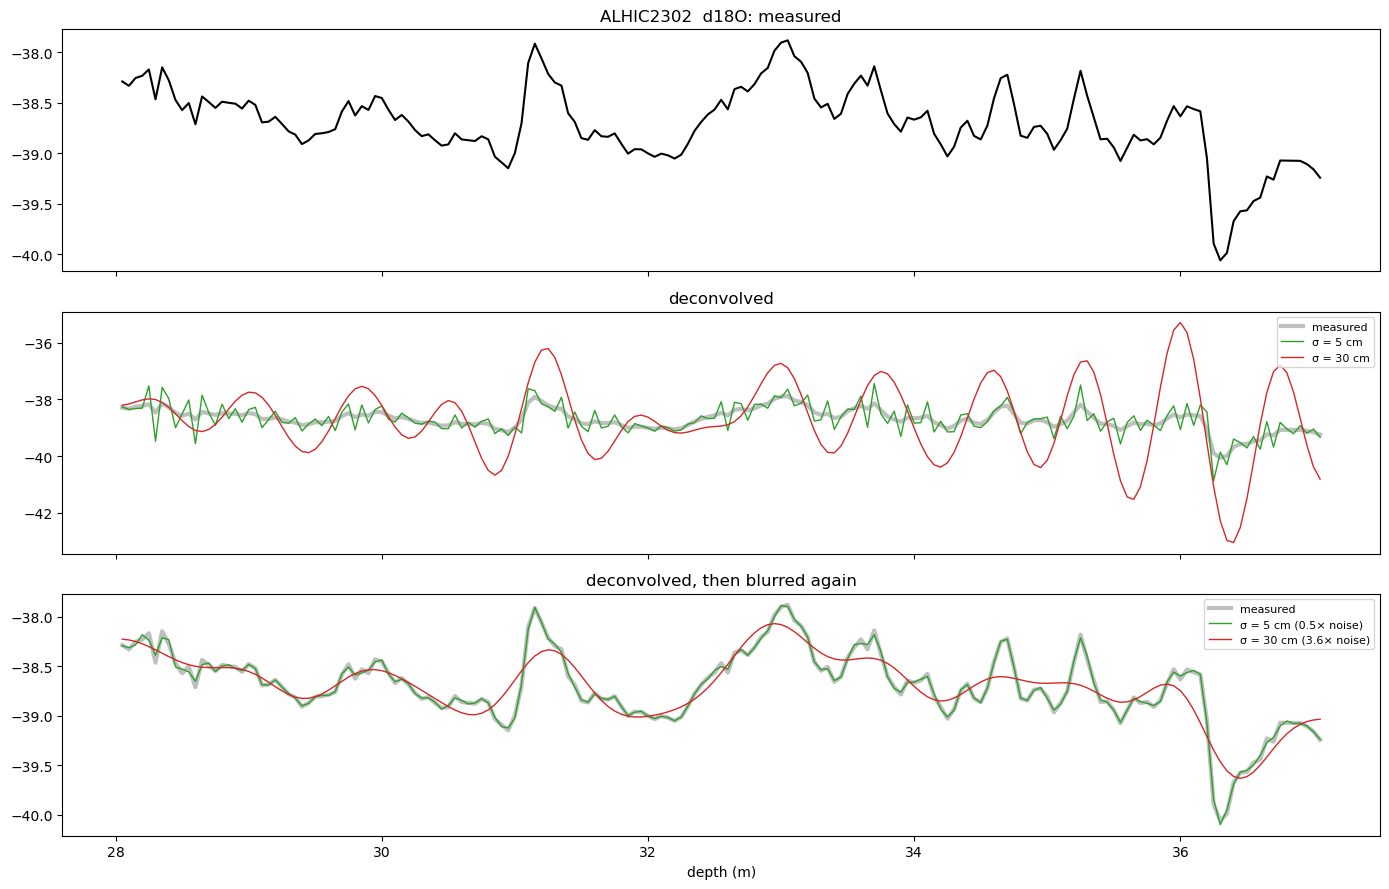

=== ALHIC2302  dD   28.05-37.05 m, 181 samples ===
noise = 0.159   K = 0.000386   measured range = 20.34


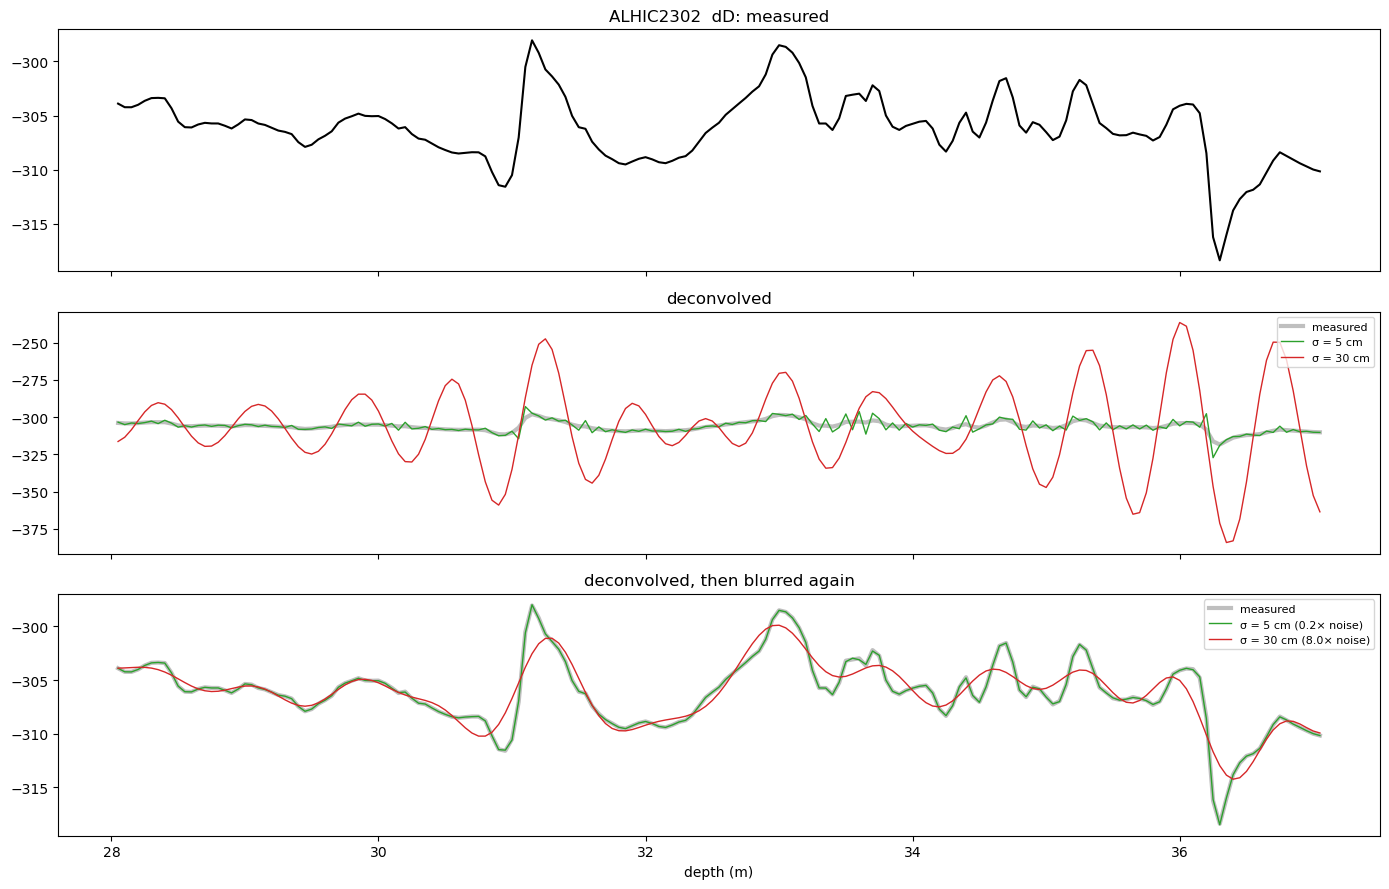

=== ALHIC2302  CH4   28.05-37.05 m, 181 samples ===
noise = 2.19   K = 0.00025   measured range = 255.13


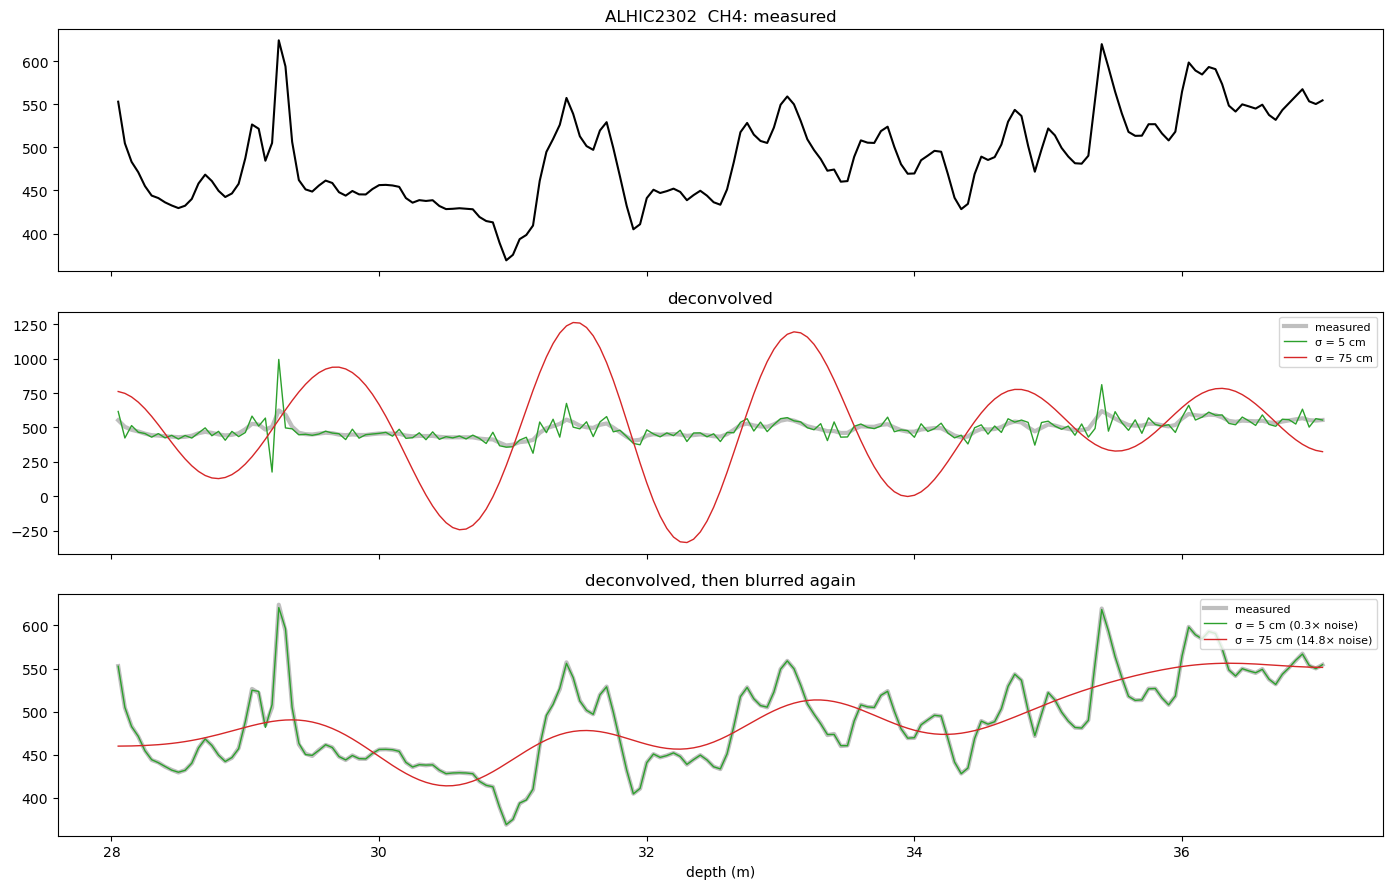

,core,proxy,measured range,noise,σ=5: range,σ=5: residual/noise,Tierney σ (cm),Tierney: range,Tierney: residual/noise
0,ALHIC2201,d18O,5.33,0.12,11.23,0.31,30,15.33,2.96
1,ALHIC2201,dD,44.64,0.89,100.75,0.37,30,134.87,3.57
2,ALHIC2201,CH4,323.81,7.30,371.10,0.15,75,1589.63,3.57
3,ALHIC2302,d18O,2.18,0.05,3.43,0.48,30,7.75,3.59
4,ALHIC2302,dD,20.34,0.16,34.26,0.23,30,147.53,8.01
5,ALHIC2302,CH4,255.13,2.19,819.84,0.29,75,1601.40,14.84


In [36]:
summary = pd.DataFrame([pipeline(core, proxy) for core in FILES for proxy in PROXIES])
summary.round(2)
